In [ ]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
# Data preparation
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")

hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT',
        'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

# exclude NAs
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
plast_chem_hazard = plast_chem_hazard.where(plast_chem_hazard['Hazard_information_Toxicity_score'] != 0.25)

# include NAs → test for sparsity algo
#plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
#plast_chem_hazard = plast_chem.where(plast_chem['Hazard_information_Toxicity_score'] != 0.25)

print(plast_chem_hazard['Hazard_information_Hazard_score'].value_counts())

# fingerprints
fps = calculate_mfps(plast_chem_hazard, 'Properties_isomeric_smiles')

mask = [fp is not None for fp in fps]
plast_chem_hazard = plast_chem_hazard[mask].copy()
fps = [fp for fp in fps if fp is not None]

X = np.vstack(fps)

Hazard_information_Hazard_score
2.0    3049
0.5    1188
1.0    1041
0.0     161
Name: count, dtype: int64


[15:20:10] WARNING: not removing hydrogen atom without neighbors
[15:20:10] WARNING: not removing hydrogen atom without neighbors
[15:20:10] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] WARNING: not removing hydrogen atom without neighbors
[15:20:11] Explicit valen

### multiclass classification
→ balance with class size? undersample neg? \
→ TODO: hyperparameter optimization

In [3]:
# data prep for multiclass
# 1, 2 hazardous; 0.5 less hazardous; 0.25 under development → exclude; 0 not hazardous
y = plast_chem_hazard['Hazard_information_Hazard_score'].replace(2, 3).replace(1, 2).replace(0.5, 1)

In [4]:
# splitting
X_train, X_split, y_train, y_split = train_test_split(X, y, test_size=0.3, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_split, y_split, test_size=0.5, stratify=y_split)

In [5]:
# create model instance
# try this but idk if it can handle multiclass
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

bst = XGBClassifier(tree_method="hist",
                    n_estimators=300,
                    max_depth=12,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric='mlogloss',
                    max_delta_step=1,
                    booster='gbtree'
                    # set to neg_class_size/pos_class_size
                    #scale_pos_weight=0.56
                    )
# fit model
bst.fit(X_train, y_train, eval_set=[(X_test, y_test)])
# make predictions
preds = bst.predict(X_val)

[0]	validation_0-mlogloss:1.23724
[1]	validation_0-mlogloss:1.22171
[2]	validation_0-mlogloss:1.20614
[3]	validation_0-mlogloss:1.19314
[4]	validation_0-mlogloss:1.18018
[5]	validation_0-mlogloss:1.16818
[6]	validation_0-mlogloss:1.15690
[7]	validation_0-mlogloss:1.14561
[8]	validation_0-mlogloss:1.13564
[9]	validation_0-mlogloss:1.12563
[10]	validation_0-mlogloss:1.11656
[11]	validation_0-mlogloss:1.10731
[12]	validation_0-mlogloss:1.09947
[13]	validation_0-mlogloss:1.09191
[14]	validation_0-mlogloss:1.08457
[15]	validation_0-mlogloss:1.07857
[16]	validation_0-mlogloss:1.07249
[17]	validation_0-mlogloss:1.06702
[18]	validation_0-mlogloss:1.06077
[19]	validation_0-mlogloss:1.05597
[20]	validation_0-mlogloss:1.05076
[21]	validation_0-mlogloss:1.04566
[22]	validation_0-mlogloss:1.04195
[23]	validation_0-mlogloss:1.03772
[24]	validation_0-mlogloss:1.03480
[25]	validation_0-mlogloss:1.03155
[26]	validation_0-mlogloss:1.02782
[27]	validation_0-mlogloss:1.02480
[28]	validation_0-mlogloss:1.0

In [8]:
print(y.value_counts(normalize=True))
y_pred_val = bst.predict(X_val)
print(accuracy_score(y_val, y_pred_val))
preds = bst.predict(X_val)
probs = bst.predict_proba(X_test)

print(classification_report(y_val, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs, multi_class='ovo'))

Hazard_information_Hazard_score
3.0    0.566133
1.0    0.211036
2.0    0.189975
0.0    0.032856
Name: proportion, dtype: float64
0.6044880785413744
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        23
         1.0       0.47      0.35      0.40       151
         2.0       0.44      0.22      0.30       135
         3.0       0.66      0.86      0.74       404

    accuracy                           0.60       713
   macro avg       0.39      0.36      0.36       713
weighted avg       0.55      0.60      0.56       713

ROC-AUC: 0.6844630586955854


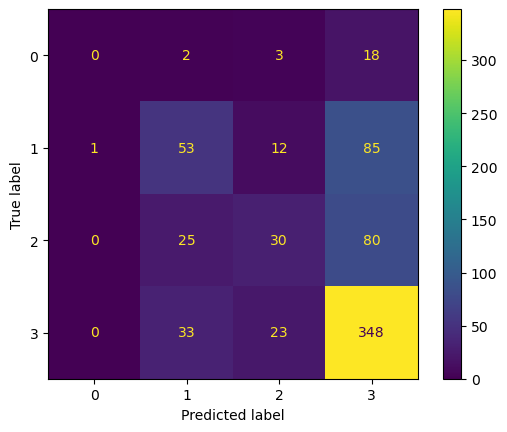

In [9]:
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(cm)#, display_labels=class_names)
disp.plot()#xticks_rotation='vertical')
plt.show()

### binary classification

In [10]:
# less hazardous and hazardous 1 and 2 get same category
y_b = plast_chem_hazard['Hazard_information_Hazard_score'].replace(0.5,1).replace(2,1).replace(3,1)
X_b = X.copy()
print(y_b.value_counts(normalize=True))

Hazard_information_Hazard_score
1.0    0.967144
0.0    0.032856
Name: proportion, dtype: float64


In [11]:
# splitting
X_train_b, X_split_b, y_train_b, y_split_b = train_test_split(X_b, y_b, test_size=0.3, stratify=y_b)
X_test_b, X_val_b, y_test_b, y_val_b = train_test_split(X_split_b, y_split_b, test_size=0.5, stratify=y_split_b)

In [12]:
# create model instance
# try this but idk if it can handle multiclass
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_b
)

bst = XGBClassifier(tree_method="hist",
                    n_estimators=300,
                    max_depth=4,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    #eval_metric='mlogloss',
                    #max_delta_step=1,
                    # set to neg_class_size/pos_class_size
                    scale_pos_weight=0.032856/0.967144
                    )
# fit model
bst.fit(X_train_b, y_train_b, eval_set=[(X_test, y_test)])
# make predictions
preds = bst.predict(X_val_b)

[0]	validation_0-logloss:0.61784
[1]	validation_0-logloss:0.58603
[2]	validation_0-logloss:0.56534
[3]	validation_0-logloss:0.52437
[4]	validation_0-logloss:0.49655
[5]	validation_0-logloss:0.46027
[6]	validation_0-logloss:0.43649
[7]	validation_0-logloss:0.41208
[8]	validation_0-logloss:0.39827
[9]	validation_0-logloss:0.38747
[10]	validation_0-logloss:0.37911
[11]	validation_0-logloss:0.36673
[12]	validation_0-logloss:0.36058
[13]	validation_0-logloss:0.34263
[14]	validation_0-logloss:0.32622
[15]	validation_0-logloss:0.31691
[16]	validation_0-logloss:0.30329
[17]	validation_0-logloss:0.30258
[18]	validation_0-logloss:0.31282
[19]	validation_0-logloss:0.31060
[20]	validation_0-logloss:0.29371
[21]	validation_0-logloss:0.26327
[22]	validation_0-logloss:0.22185
[23]	validation_0-logloss:0.20682
[24]	validation_0-logloss:0.20958
[25]	validation_0-logloss:0.19994
[26]	validation_0-logloss:0.18493
[27]	validation_0-logloss:0.16648
[28]	validation_0-logloss:0.15642
[29]	validation_0-loglos

In [13]:
print(y_b.value_counts(normalize=True))
y_pred_val_b = bst.predict(X_val_b)
print(accuracy_score(y_val_b, y_pred_val_b))

preds_b = bst.predict(X_val_b)
probs = bst.predict_proba(X_test_b)

print(classification_report(y_val_b, preds_b))

Hazard_information_Hazard_score
1.0    0.967144
0.0    0.032856
Name: proportion, dtype: float64
0.8022440392706872
              precision    recall  f1-score   support

         0.0       0.10      0.58      0.17        24
         1.0       0.98      0.81      0.89       689

    accuracy                           0.80       713
   macro avg       0.54      0.70      0.53       713
weighted avg       0.95      0.80      0.86       713



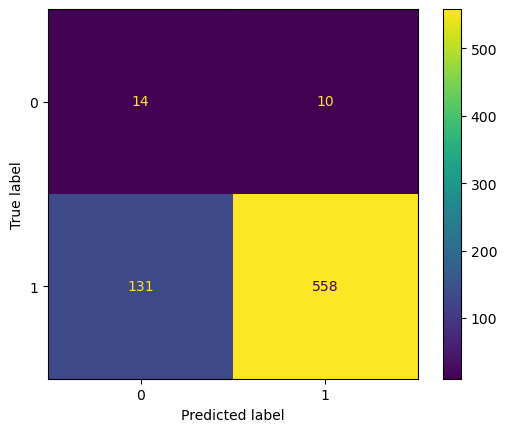

In [14]:
cm = confusion_matrix(y_val_b, preds_b)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

### Regression

In [15]:
y_r = plast_chem_hazard['Hazard_information_Hazard_score']
print(y_r.value_counts())
X_r = X.copy()

Hazard_information_Hazard_score
2.0    2688
0.5    1002
1.0     902
0.0     156
Name: count, dtype: int64


In [16]:
# splitting
X_train_r, X_split_r, y_train_r, y_split_r = train_test_split(X_r, y_r, test_size=0.3, stratify=y_r)
X_test_r, X_val_r, y_test_r, y_val_r = train_test_split(X_split_r, y_split_r, test_size=0.5, stratify=y_split_r)

In [17]:
# create model instance
# try this but idk if it can handle multiclass
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_b
)

bst = XGBRegressor(tree_method="hist",
                    n_estimators=300,
                    max_depth=4,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    #eval_metric='mlogloss',
                    #max_delta_step=1,
                    )
# fit model
bst.fit(X_train_r, y_train_r, eval_set=[(X_test_r, y_test_r)])
# make predictions
preds = bst.predict(X_val_r)

[0]	validation_0-rmse:0.68053
[1]	validation_0-rmse:0.67621
[2]	validation_0-rmse:0.67252
[3]	validation_0-rmse:0.66968
[4]	validation_0-rmse:0.66721
[5]	validation_0-rmse:0.66402
[6]	validation_0-rmse:0.66204
[7]	validation_0-rmse:0.66013
[8]	validation_0-rmse:0.65842
[9]	validation_0-rmse:0.65759
[10]	validation_0-rmse:0.65627
[11]	validation_0-rmse:0.65424
[12]	validation_0-rmse:0.65312
[13]	validation_0-rmse:0.65186
[14]	validation_0-rmse:0.65196
[15]	validation_0-rmse:0.65151
[16]	validation_0-rmse:0.65058
[17]	validation_0-rmse:0.64995
[18]	validation_0-rmse:0.64945
[19]	validation_0-rmse:0.64924
[20]	validation_0-rmse:0.64858
[21]	validation_0-rmse:0.64847
[22]	validation_0-rmse:0.64742
[23]	validation_0-rmse:0.64732
[24]	validation_0-rmse:0.64743
[25]	validation_0-rmse:0.64699
[26]	validation_0-rmse:0.64720
[27]	validation_0-rmse:0.64649
[28]	validation_0-rmse:0.64616
[29]	validation_0-rmse:0.64589
[30]	validation_0-rmse:0.64566
[31]	validation_0-rmse:0.64586
[32]	validation_0-

In [19]:
y_pred_val_r = bst.predict(X_val_r)
print(f'MAE: {mean_absolute_error(y_val_r, y_pred_val_r)}')

print(f'RMSE: {root_mean_squared_error(y_val_r, y_pred_val_r)}')

corr, p = spearmanr(y_val_r, y_pred_val_r)

print(f'Spearmans Corr: {corr}')
print(y_r.value_counts())

print(r2_score(y_val_r, y_pred_val_r))

MAE: 0.5238542548402998
RMSE: 0.619044250675097
Spearmans Corr: 0.4320508715152861
Hazard_information_Hazard_score
2.0    2688
0.5    1002
1.0     902
0.0     156
Name: count, dtype: int64
0.18157498935792693


In [ ]:
# check baseline
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_r, y_train_r)

dummy_pred = dummy.predict(X_val_r)

print("Dummy MAE:", mean_absolute_error(y_val_r, dummy_pred))
print("Dummy R²:", r2_score(y_val_r, dummy_pred))

Dummy MAE: 0.6477717670922919
Dummy R²: -1.032007752588271e-06
[1.42777611 1.42777611 1.42777611 1.42777611 1.42777611 1.42777611
 1.42777611 1.42777611 1.42777611 1.42777611]
